In [9]:
# Force widget backend BEFORE any hyperspy/matplotlib imports
# This must be the very first cell run after a kernel restart
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # reset any cached backend

%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import hyperspy.api as hs
import lumispy as lum
from h5py import File

# Tell HyperSpy explicitly to use the widget toolkit
hs.preferences.GUIs.warn_if_guis_are_not_installed = False
hs.preferences.Plot.widget_plot_style = 'horizontal'

import matplotlib
print(f'Backend active: {matplotlib.get_backend()}')
print('✅ If backend shows module://ipympl... the slider will work inline.')
print('⚠️  If backend shows Qt, run: pip install ipympl --upgrade, then restart kernel.')


Backend active: widget
✅ If backend shows module://ipympl... the slider will work inline.
⚠️  If backend shows Qt, run: pip install ipympl --upgrade, then restart kernel.


In [10]:
def load_map(file_path, dataset_path):
    r''' Loads numpy array from .h5 delmic file.
    file path - location of .h5
    dataset_path - location of 
    '''
    with File(file_path, 'r') as f:
        data = f[dataset_path][()]  
    return data

In [11]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import hyperspy.api as hs
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
from datetime import datetime
import tkinter as tk
from tkinter import filedialog
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore', module='rsciio')

# Default base directories
RAW_DATA_DIR       = r'C:\Users\jonny\Lehigh University Dropbox\ENG-MATSGroup\MATS\Data\Raw - Data'
LITERATURE_DIR     = r'C:\Users\jonny\Lehigh University Dropbox\ENG-MATSGroup\MATS\Data\Parsers\PeakSeek\Literature Data'
OUTPUT_DIR         = r'C:\Users\jonny\Lehigh University Dropbox\ENG-MATSGroup\MATS\Data\Processed - Sample'

# Shared state — these get populated by the file dialogs below
selected_files = {
    'data':    None,
    'literature': None,
    'output_dir': OUTPUT_DIR,
}

# --- Helper: open a tkinter dialog without showing the root window ---
def _tk_dialog(func, **kwargs):
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    result = func(**kwargs)
    root.destroy()
    return result

# --- Labels showing current selections ---
data_label = widgets.Label(value='No file selected')
lit_label  = widgets.Label(value='No file selected')
out_label  = widgets.Label(value=OUTPUT_DIR)

# --- Buttons ---
btn_data = widgets.Button(
    description='Browse Raw Data (.h5)',
    button_style='primary',
    layout=widgets.Layout(width='220px')
)
btn_lit = widgets.Button(
    description='Browse Literature (.xlsx)',
    button_style='primary',
    layout=widgets.Layout(width='220px')
)
btn_out = widgets.Button(
    description='Browse Output Folder',
    button_style='warning',
    layout=widgets.Layout(width='220px')
)
btn_confirm = widgets.Button(
    description='✅ Confirm & Load Data',
    button_style='success',
    layout=widgets.Layout(width='220px')
)
status_label = widgets.Label(value='')

def on_browse_data(b):
    path = _tk_dialog(
        filedialog.askopenfilename,
        title='Select Raw CL/PL Data File',
        initialdir=RAW_DATA_DIR,
        filetypes=[('HDF5 files', '*.h5'), ('All files', '*.*')]
    )
    if path:
        selected_files['data'] = path
        data_label.value = os.path.basename(path)

def on_browse_lit(b):
    path = _tk_dialog(
        filedialog.askopenfilename,
        title='Select Literature Peaks File',
        initialdir=LITERATURE_DIR,
        filetypes=[('Excel files', '*.xlsx *.xls'), ('All files', '*.*')]
    )
    if path:
        selected_files['literature'] = path
        lit_label.value = os.path.basename(path)

def on_browse_out(b):
    folder = _tk_dialog(
        filedialog.askdirectory,
        title='Select Output Folder',
        initialdir=OUTPUT_DIR,
    )
    if folder:
        selected_files['output_dir'] = folder
        out_label.value = folder

def on_confirm(b):
    if not selected_files['data']:
        status_label.value = '⚠️  Please select a raw data file first.'
        return
    if not selected_files['literature']:
        status_label.value = '⚠️  Please select a literature peaks file first.'
        return

    # Load data and store everything in selected_files dict
    # (avoids unreliable global assignment from within widget callbacks)
    try:
        selected_files['raw_data'] = load_map(selected_files['data'], 'Acquisition2/ImageData/Image')
        selected_files['data_squeezed'] = selected_files['raw_data'].squeeze()
        selected_files['confirmed'] = True
        status_label.value = (
            f"✅ Loaded: {os.path.basename(selected_files['data'])}  |  "
            f"Literature: {os.path.basename(selected_files['literature'])}  |  "
            f"Output: {selected_files['output_dir']}"
        )
    except Exception as e:
        status_label.value = f'❌ Error loading data: {e}'

btn_data.on_click(on_browse_data)
btn_lit.on_click(on_browse_lit)
btn_out.on_click(on_browse_out)
btn_confirm.on_click(on_confirm)

# --- Layout ---
display(widgets.HTML('<b>── Input Files ──────────────────────────────</b>'))
display(widgets.HBox([btn_data, data_label]))
display(widgets.HBox([btn_lit,  lit_label]))
display(widgets.HTML('<b>── Output Folder ────────────────────────────</b>'))
display(widgets.HBox([btn_out,  out_label]))
display(widgets.HTML('<b>─────────────────────────────────────────────</b>'))
display(btn_confirm)
display(status_label)


HTML(value='<b>── Input Files ──────────────────────────────</b>')

HTML(value='<b>── Output Folder ────────────────────────────</b>')

HTML(value='<b>─────────────────────────────────────────────</b>')

Button(button_style='success', description='✅ Confirm & Load Data', layout=Layout(width='220px'), style=Button…

Label(value='')

✅ Using data:       240326TE_S2_CL_5kV_1p6nA_1200_8K_005.h5
✅ Using literature: 260326TE_S2_005_peaks_260310.xlsx
✅ Output folder:    C:/Users/jonny/Lehigh University Dropbox/ENG-MATSGroup/MATS/Data/Processed - Sample/24/2403/240326TE_S2/CL - Delmic/PeakSeek/240326TE_S2_CL_5kV_1p6nA_1200_8K_004


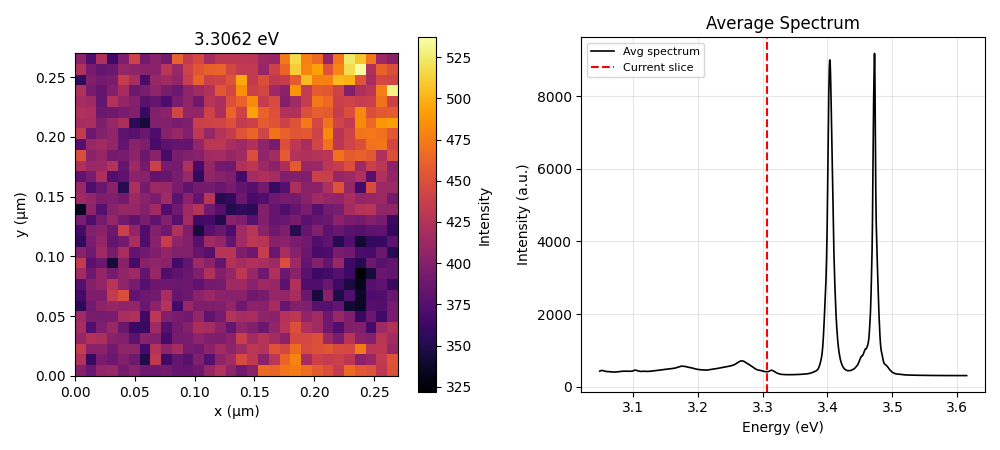

Drag the slider or type an exact eV value and press Enter. Click 💾 Save Explorer to export the current view — press multiple times for multiple saves.


In [5]:
# --- GUARD: ensure files have been selected and confirmed in Cell 2 ---
if not selected_files.get('confirmed'):
    raise RuntimeError('⚠️  Please run Cell 2 and click "✅ Confirm & Load Data" first.')

# Assign from selected_files dict — reliable across Jupyter cells
path       = selected_files['data']
excel_path = selected_files['literature']
output_dir = selected_files['output_dir']
raw_data   = selected_files['raw_data']
data       = selected_files['data_squeezed']

print(f'✅ Using data:       {os.path.basename(path)}')
print(f'✅ Using literature: {os.path.basename(excel_path)}')
print(f'✅ Output folder:    {output_dir}')

import ipywidgets as widgets
from IPython.display import display

# --- SINGLE-SPECTRUM GUARD ---
# The explorer requires a 3-D hyperspectral cube (energy × y × x).
# If only a single spectrum was loaded, warn the user and stop gracefully.
_d_check = raw_data.squeeze()
if _d_check.ndim < 3:
    display(widgets.HTML(
        '<div style="padding:10px 14px;background:#fff3cd;border:2px solid #ffc107;'
        'border-radius:6px;font-size:13px;">'
        '<b>⚠️  Single spectrum detected — Energy Explorer cannot run.</b><br>'
        f'Data shape after squeeze: <code>{_d_check.shape}</code><br>'
        'The Energy Explorer expects a 3-D hyperspectral cube '
        '(energy&nbsp;×&nbsp;y&nbsp;×&nbsp;x). '
        'For a single spectrum please use the '
        '<b>Average / Single Spectrum Viewer</b> cell below.'
        '</div>'
    ))
    raise StopIteration('Single spectrum — use the Spectrum Viewer cell.')

# --- BUILD DATA CUBE ---
hc = 1239.84193
wavelengths = load_map(path, 'Acquisition2/ImageData/DimensionScaleC') * 1e9
energy_axis = np.sort(hc / wavelengths)

data_work = raw_data.squeeze()
if data_work.shape[-1] > data_work.shape[0]:
    data_work = data_work.transpose(2, 0, 1)
data_work = np.flip(data_work, axis=0).copy()  # shape: (energy, y, x)

avg_spectrum = np.mean(data_work, axis=(1, 2))

# --- FIGURE ---
fig_explore, (ax_map, ax_spec) = plt.subplots(1, 2, figsize=(11, 5.5))
plt.subplots_adjust(wspace=0.35)

n_energies = data_work.shape[0]
init_idx = n_energies // 2
init_ev  = float(energy_axis[init_idx])

# Left panel: spatial map
im = ax_map.imshow(
    data_work[init_idx],
    origin='lower',
    extent=[0, data_work.shape[2] * 0.009,
            0, data_work.shape[1] * 0.009],
    cmap='inferno'
)
map_title = ax_map.set_title(f'{init_ev:.4f} eV')
ax_map.set_xlabel('x (μm)')
ax_map.set_ylabel('y (μm)')
plt.colorbar(im, ax=ax_map, label='Intensity')
ax_map.tick_params(which='both', direction='in', top=True, right=True)
ax_map.set_box_aspect(1)

# Right panel: average spectrum + tracking line
ax_spec.plot(energy_axis, avg_spectrum, color='black', linewidth=1.2, label='Avg spectrum')
vline = ax_spec.axvline(x=init_ev, color='red', linewidth=1.5, linestyle='--', label='Current slice')
ax_spec.set_xlabel('Energy (eV)')
ax_spec.set_ylabel('Intensity (a.u.)')
ax_spec.set_title('Average Spectrum')
ax_spec.legend(fontsize=8)
ax_spec.grid(True, alpha=0.3)
ax_spec.tick_params(which='both', direction='in', top=True, right=True)
ax_spec.set_box_aspect(1)
plt.tight_layout()

# --- UPDATE FUNCTION ---
# Snaps requested eV to nearest real axis value and updates both panels
_updating = False  # guard to prevent slider and text box triggering each other

def update_map(ev):
    idx = int(np.argmin(np.abs(energy_axis - ev)))
    snapped_ev = float(energy_axis[idx])
    im.set_data(data_work[idx])
    im.set_clim(vmin=data_work[idx].min(), vmax=data_work[idx].max())
    map_title.set_text(f'{snapped_ev:.4f} eV')
    vline.set_xdata([snapped_ev, snapped_ev])
    fig_explore.canvas.draw_idle()
    return snapped_ev

# --- SLIDER ---
slider = widgets.SelectionSlider(
    options=[(f'{ev:.4f} eV', float(ev)) for ev in energy_axis],
    value=init_ev,
    description='Energy:',
    continuous_update=True,
    layout=widgets.Layout(width='600px')
)

# --- TEXT BOX ---
# User types an exact eV value and presses Enter — snaps to nearest measured energy
text_box = widgets.BoundedFloatText(
    value=init_ev,
    min=float(energy_axis.min()),
    max=float(energy_axis.max()),
    step=0.0001,
    description='Go to eV:',
    continuous_update=False,  # only fires on Enter or focus loss
    layout=widgets.Layout(width='200px')
)
snap_label = widgets.Label(value=f'Snapped to: {init_ev:.4f} eV')

# --- CALLBACKS ---
def on_slider_change(change):
    global _updating
    if _updating: return
    _updating = True
    snapped = update_map(change['new'])
    text_box.value = snapped
    snap_label.value = f'Snapped to: {snapped:.4f} eV'
    _updating = False

def on_text_change(change):
    global _updating
    if _updating: return
    _updating = True
    snapped = update_map(change['new'])
    slider.value = snapped          # move slider to match
    snap_label.value = f'Snapped to: {snapped:.4f} eV'
    _updating = False

slider.observe(on_slider_change, names='value')
text_box.observe(on_text_change, names='value')

# --- LOG SCALE TOGGLES ---
map_log_toggle = widgets.ToggleButton(
    value=False, description='Map: Log scale',
    button_style='', icon='check',
    layout=widgets.Layout(width='150px')
)
spec_log_toggle = widgets.ToggleButton(
    value=False, description='Spectrum: Log scale',
    button_style='', icon='check',
    layout=widgets.Layout(width='170px')
)

def on_map_log_toggle(change):
    if change['new']:
        im.set_norm(matplotlib.colors.LogNorm(
            vmin=max(data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].min(), 1e-6),
            vmax=data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].max()
        ))
    else:
        im.set_norm(matplotlib.colors.Normalize(
            vmin=data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].min(),
            vmax=data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].max()
        ))
    fig_explore.canvas.draw_idle()

def on_spec_log_toggle(change):
    ax_spec.set_yscale('log' if change['new'] else 'linear')
    fig_explore.canvas.draw_idle()

map_log_toggle.observe(on_map_log_toggle, names='value')
spec_log_toggle.observe(on_spec_log_toggle, names='value')

# --- LAYOUT ---
# --- EXPORT BUTTON for energy explorer ---
export_counter = {'n': 0}  # mutable counter so callback can increment it

def save_explorer(b):
    export_counter['n'] += 1
    ev_str = f"{slider.value:.4f}eV".replace('.', 'p')
    fname = os.path.join(
        output_dir,
        f"{os.path.splitext(os.path.basename(path))[0]}_Explorer_{ev_str}_export{export_counter['n']}.png"
    )
    fig_explore.savefig(fname, dpi=150, bbox_inches='tight')
    save_explorer_btn.description = f'✅ PNG ({export_counter["n"]})'
    save_explorer_btn.button_style = 'success'

def save_explorer_svg(b):
    export_counter['n'] += 1
    ev_str = f"{slider.value:.4f}eV".replace('.', 'p')
    fname = os.path.join(
        output_dir,
        f"{os.path.splitext(os.path.basename(path))[0]}_Explorer_{ev_str}_export{export_counter['n']}.svg"
    )
    fig_explore.savefig(fname, bbox_inches='tight')
    save_explorer_svg_btn.description = f'✅ SVG ({export_counter["n"]})'
    save_explorer_svg_btn.button_style = 'success'

save_explorer_btn = widgets.Button(
    description='💾 Save PNG',
    button_style='warning',
    layout=widgets.Layout(width='140px')
)
save_explorer_svg_btn = widgets.Button(
    description='💾 Save SVG',
    button_style='warning',
    layout=widgets.Layout(width='140px')
)
save_explorer_btn.on_click(save_explorer)
save_explorer_svg_btn.on_click(save_explorer_svg)

display(widgets.HBox([slider, text_box]))
display(widgets.HBox([snap_label]))
display(widgets.HBox([map_log_toggle, spec_log_toggle, save_explorer_btn, save_explorer_svg_btn]))
plt.show()
print('Drag the slider or type an exact eV value and press Enter. '
      'Click 💾 Save Explorer to export the current view — press multiple times for multiple saves.')

In [12]:
# --- GUARD: ensure files have been selected and confirmed in Cell 2 ---
if not selected_files.get('confirmed'):
    raise RuntimeError('⚠️  Please run Cell 2 and click "✅ Confirm & Load Data" first.')

path       = selected_files['data']
excel_path = selected_files['literature']
output_dir = selected_files['output_dir']
raw_data   = selected_files['raw_data']
data       = selected_files['data_squeezed']

print(f'✅ Using data:       {os.path.basename(path)}')
print(f'✅ Using literature: {os.path.basename(excel_path)}')
print(f'✅ Output folder:    {output_dir}')

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib
from scipy.optimize import curve_fit

hc = 1239.84193

# ═══════════════════════════════════════════════════════════════════
# FITTING PARAMETER CONTROLS
# Adjust sliders then click ▶ Run Fit.
# ═══════════════════════════════════════════════════════════════════

style  = {'description_width': '200px'}
layout = widgets.Layout(width='500px')

w_fit_tolerance = widgets.FloatSlider(
    value=8.0, min=1.0, max=50.0, step=1.0,
    description='Centre tolerance (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_fit_tolerance_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">How far the fitted centre can shift from the '
    'literature position. Increase for strained or temperature-shifted samples.</i>'
)

w_csv_tolerance = widgets.FloatSlider(
    value=50.0, min=5.0, max=200.0, step=5.0,
    description='CSV match tolerance (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_csv_tolerance_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Peak reported as FOUND in CSV if fitted centre '
    'is within this distance of the literature value.</i>'
)

w_sigma_init = widgets.FloatSlider(
    value=5.0, min=0.5, max=30.0, step=0.5,
    description='Sigma start (meV):',
    style=style, layout=layout, readout_format='.1f',
)
w_sigma_init_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Initial guess for peak width. '
    'For low-T CL (&lt;50K) use 3–8 meV. For room temperature use 20–30 meV. '
    'Tighter starting values improve convergence for narrow peaks.</i>'
)

w_sigma_min = widgets.FloatSlider(
    value=2.0, min=0.001, max=15.0, step=0.001,
    description='Sigma min (meV):',
    style=style, layout=layout, readout_format='.3f',
)
w_sigma_min_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Minimum allowed peak width. '
    'Prevents fitter collapsing onto an unphysically sharp noise spike.</i>'
)

w_sigma_max = widgets.FloatSlider(
    value=12.0, min=0.001, max=100.0, step=0.001,
    description='Sigma max (meV):',
    style=style, layout=layout, readout_format='.3f',
)
w_sigma_max_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Maximum allowed peak width. '
    'Low-T CL: 10–15 meV. Mid-T: 20–40 meV. Room-T: 40–80 meV.<br>'
    'Only used when Shared Sigma mode is Off.</i>'
)

w_shared_sigma = widgets.ToggleButtons(
    options=[('Off (per-peak)', 'off'), ('Auto (fit strongest peak)', 'auto'),
             ('Manual (set below)', 'manual')],
    value='auto',
    description='Shared sigma:',
    style={'description_width': '200px', 'button_width': '185px'},
)
w_shared_sigma_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    '<b>Off:</b> sigma fitted independently per peak (unreliable when peaks overlap).<br>'
    '<b>Auto:</b> sigma fitted on the strongest peak in the spectrum, '
    'then applied to all peaks. Reliable when instrumental broadening dominates.<br>'
    '<b>Manual:</b> sigma fixed at the value set by the slider below.</i>'
)
w_sigma_manual = widgets.FloatSlider(
    value=3.0, min=0.5, max=30.0, step=0.5,
    description='Manual sigma (meV):',
    style=style, layout=layout, readout_format='.1f',
)
w_sigma_manual_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    'Fixed sigma applied to all peaks when Manual mode is selected. '
    'Start from the Auto-estimated value and adjust up/down to improve the fit.</i>'
)
sigma_manual_box = widgets.VBox([w_sigma_manual, w_sigma_manual_info])
sigma_manual_box.layout.display = 'none'

def on_shared_sigma_change(change):
    sigma_manual_box.layout.display = 'flex' if change['new'] == 'manual' else 'none'
w_shared_sigma.observe(on_shared_sigma_change, names='value')

w_snr = widgets.FloatSlider(
    value=1.0, min=0.1, max=10.0, step=0.1,
    description='SNR threshold (%):',
    style=style, layout=layout, readout_format='.1f',
)
w_snr_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Peak must exceed this % of spectrum max above '
    'local background to be fitted. Lower = detect weaker peaks; raise = suppress noise.</i>'
)

w_clip_to_lit = widgets.Checkbox(
    value=False,
    description='Clip spectrum to literature range',
    style={'description_width': '260px'},
    layout=widgets.Layout(width='420px')
)
w_clip_to_lit_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    'When checked, restricts all fitting and plots to the energy range spanned by '
    'the in-range literature peaks (min peak − window to max peak + window). '
    'Removes irrelevant spectral background on either side and focuses the '
    'NNLS solve and residual plot on only the region being modelled.</i>'
)

w_amp_ceiling = widgets.FloatSlider(
    value=1.5, min=1.0, max=5.0, step=0.1,
    description='Amplitude ceiling (×):',
    style=style, layout=layout, readout_format='.1f',
)
w_amp_ceiling_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Upper bound on fitted amplitude as a multiple of '
    'the local background-subtracted peak maximum. 1.0 = no overshoot allowed. '
    '1.5 = up to 50% above the estimated peak height. '
    'Reduce if the model consistently overshoots the data.</i>'
)

w_window = widgets.FloatSlider(
    value=80.0, min=20.0, max=300.0, step=5.0,
    description='Fit window (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_window_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">±Width of data slice used per peak fit. '
    'Wide enough for background subtraction at edges, narrow enough to exclude neighbours.</i>'
)

w_n_restarts = widgets.IntSlider(
    value=5, min=1, max=30, step=1,
    description='Fit restarts:',
    style=style, layout=layout,
)
w_n_restarts_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Number of times each peak fit is attempted with '
    'randomly perturbed starting parameters. The result with the lowest chi-squared is kept. '
    'More restarts = more robust fit but slower. 1 = single fit (original behaviour).</i>'
)

w_centre_mode = widgets.ToggleButtons(
    options=[('Fit centre (Phase 1)', 'fit'), ('Lock to literature', 'lock')],
    value='fit',
    description='Centre mode:',
    style={'description_width': '200px', 'button_width': '210px'},
)
w_centre_mode_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    '<b>Fit centre:</b> Phase 1 fits centre and sigma freely within the tolerance window.<br>'
    '<b>Lock to literature:</b> centre is fixed at the literature position. '
    'Only sigma is fitted. Best for shoulder peaks that drift into a dominant neighbour.</i>'
)

w_tikhonov = widgets.FloatLogSlider(
    value=0.01, base=10, min=-4, max=2, step=0.5,
    description='λ regularisation:',
    style=style, layout=layout, readout_format='.2e',
)
w_tikhonov_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    'Tikhonov regularisation strength for the NNLS amplitude solve. '
    'A small λ (&gt;0) penalises driving shoulder peak amplitudes to zero, '
    'preserving peaks that would otherwise collapse into a dominant neighbour.<br>'
    '0.0001 = very weak (nearly pure NNLS) | 0.01 = moderate | 1.0 = strong.<br>'
    'Increase if shoulders are collapsing; decrease if amplitudes are inflated.</i>'
)

# --- Background mode ---
w_bg_mode = widgets.ToggleButtons(
    options=[('Local (per peak)', 'local'), ('Global (whole spectrum)', 'global')],
    value='local',
    description='Background:',
    style={'description_width': '200px', 'button_width': '200px'},
)
w_bg_mode_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    '<b>Local:</b> fits a linear baseline within each peak window individually — '
    'best for spectra with uneven or structured background.<br>'
    '<b>Global:</b> fits a single polynomial to the whole spectrum first, subtracts it once, '
    'then fits all peaks on the cleaned spectrum — best for a smooth slowly varying background.</i>'
)
w_bg_order = widgets.IntSlider(
    value=1, min=1, max=5, step=1,
    description='Global BG poly order:',
    style=style, layout=layout,
)
w_bg_order_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    'Polynomial order for the global background. '
    '1 = linear, 2 = quadratic, 3 = cubic. Only used in Global mode. '
    'Higher orders follow the background more closely but risk overfitting.</i>'
)
w_bg_percentile = widgets.IntSlider(
    value=20, min=5, max=50, step=5,
    description='BG percentile (%):',
    style=style, layout=layout,
)
w_bg_percentile_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    'Percentage of lowest-intensity spectral points used as background anchors. '
    'These points are assumed to lie in baseline regions between peaks. '
    'A polynomial is then fitted through them only.<br>'
    '10–20% works well for dense peak spectra. '
    'Increase if the background is underestimated; decrease if peaks are included.</i>'
)

bg_order_box = widgets.VBox([w_bg_order, w_bg_order_info,
                             w_bg_percentile, w_bg_percentile_info])
bg_order_box.layout.display = 'none'

def on_bg_mode_change(change):
    bg_order_box.layout.display = 'flex' if change['new'] == 'global' else 'none'
w_bg_mode.observe(on_bg_mode_change, names='value')

run_btn    = widgets.Button(description='▶  Run Fit', button_style='primary',
                            layout=widgets.Layout(width='160px'))
fit_status = widgets.Label(value='Adjust parameters then click ▶ Run Fit.')
out_area   = widgets.Output()

param_box = widgets.VBox([
    widgets.HTML('<b>── Peak Centre ─────────────────────────────────────────</b>'),
    w_fit_tolerance, w_fit_tolerance_info,
    w_csv_tolerance, w_csv_tolerance_info,
    widgets.HTML('<b>── Peak Width (Sigma) ──────────────────────────────────</b>'),
    w_sigma_init, w_sigma_init_info,
    w_sigma_min,  w_sigma_min_info,
    w_sigma_max,       w_sigma_max_info,
    w_shared_sigma,    w_shared_sigma_info,
    sigma_manual_box,
    widgets.HTML('<b>── Peak Detection ──────────────────────────────────────</b>'),
    w_snr,        w_snr_info,
    w_window,      w_window_info,
    w_clip_to_lit, w_clip_to_lit_info,
    w_amp_ceiling, w_amp_ceiling_info,
    widgets.HTML('<b>── Fit Robustness ──────────────────────────────────────</b>'),
    w_n_restarts,   w_n_restarts_info,
    widgets.HTML('<b>── Shoulder / Overlap Handling ──────────────────────────────────</b>'),
    w_centre_mode,  w_centre_mode_info,
    w_tikhonov,     w_tikhonov_info,
    widgets.HTML('<b>── Background ──────────────────────────────────────────</b>'),
    w_bg_mode,    w_bg_mode_info,
    bg_order_box,
    widgets.HTML('<b>───────────────────────────────────────────────────────</b>'),
    run_btn,
    fit_status,
    out_area,
])
display(param_box)


def run_fit(b=None):
    global fitted_params, df_results, fig1, ax1, fig2, ax2, fig3, ax3_top, ax3_bot
    global base_name, timestamp, output_csv_name, energy_axis, spec_data_1d

    # Read all widget values
    bg_mode       = w_bg_mode.value
    bg_order      = w_bg_order.value
    bg_percentile = w_bg_percentile.value
    fit_tolerance = w_fit_tolerance.value / 1000
    tolerance     = w_csv_tolerance.value / 1000
    sigma0_val    = w_sigma_init.value    / 1000
    sigma_min     = w_sigma_min.value     / 1000
    sigma_max     = w_sigma_max.value     / 1000
    shared_sigma  = w_shared_sigma.value
    sigma_manual  = w_sigma_manual.value  / 1000
    snr_threshold = w_snr.value           / 100
    window        = w_window.value        / 1000
    clip_to_lit   = w_clip_to_lit.value
    amp_ceiling   = w_amp_ceiling.value
    n_restarts    = w_n_restarts.value
    centre_mode   = w_centre_mode.value
    lam           = w_tikhonov.value      # Tikhonov regularisation lambda

    base_name       = os.path.splitext(os.path.basename(path))[0]
    timestamp       = datetime.now().strftime('%m%y%d_%H%M%S')
    output_csv_name = os.path.join(output_dir, f"{base_name}_PeakSearch_{timestamp}.csv")

    fit_status.value = '⏳ Running fit...'

    with out_area:
        clear_output(wait=True)

        # --- 1. DATA PREP ---
        raw  = load_map(path, 'Acquisition2/ImageData/Image')
        d    = raw.squeeze()
        wl   = load_map(path, 'Acquisition2/ImageData/DimensionScaleC') * 1e9
        energy_axis = np.sort(hc / wl)

        # Handle cube, line scan, or single spectrum
        if d.ndim == 3:
            if d.shape[-1] == len(energy_axis):
                d = d.transpose(2, 0, 1)   # (Y, X, E) → (E, Y, X)
            spec_data_1d = np.flip(np.mean(d, axis=(1, 2)).flatten())
        elif d.ndim == 2:
            ax_sp = 0 if d.shape[1] == len(energy_axis) else 1
            spec_data_1d = np.flip(np.mean(d, axis=ax_sp).flatten())
        elif d.ndim == 1:
            spec_data_1d = np.flip(d.copy())
        else:
            raise ValueError(f'Unexpected data shape: {d.shape}')

        # --- 2. LITERATURE PEAKS ---
        df_lit   = pd.read_excel(excel_path)
        in_range = df_lit[
            (df_lit['Peak_eV'] >= energy_axis.min()) &
            (df_lit['Peak_eV'] <= energy_axis.max())
        ].copy()

        print(f"Loaded {len(df_lit)} literature peaks, {len(in_range)} within range "
              f"({energy_axis.min():.3f} – {energy_axis.max():.3f} eV).")

        # --- Clip spectrum to literature range (optional) ---
        if clip_to_lit and len(in_range) > 0:
            lit_min = in_range['Peak_eV'].min() - window
            lit_max = in_range['Peak_eV'].max() + window
            clip_mask    = (energy_axis >= lit_min) & (energy_axis <= lit_max)
            energy_axis  = energy_axis[clip_mask]
            spec_data_1d = spec_data_1d[clip_mask]
            print(f"  ✂️  Spectrum clipped to literature range: "
                  f"{energy_axis.min():.4f} – {energy_axis.max():.4f} eV "
                  f"({len(energy_axis)} points)")
        print(f"Parameters: centre ±{fit_tolerance*1000:.0f} meV | "
              f"σ {sigma_min*1000:.1f}–{sigma_max*1000:.0f} meV (start {sigma0_val*1000:.1f}) | "
              f"SNR >{snr_threshold*100:.1f}% | window ±{window*1000:.0f} meV | "
              f"restarts {n_restarts} | centre: {centre_mode} | λ={lam:.2e} | "
              f"bg: {bg_mode}"
              f"{'  (order '+str(bg_order)+')' if bg_mode=='global' else ''}\n")

        # --- 2b. GLOBAL BACKGROUND ---
        if bg_mode == 'global':
            # Percentile-based background: use the lowest bg_percentile% of
            # spectral points as anchors. These naturally fall in baseline
            # regions without needing to locate peak-free windows explicitly.
            threshold     = np.percentile(spec_data_1d, bg_percentile)
            bg_mask       = spec_data_1d <= threshold

            # Require at least bg_order+2 points; relax threshold if needed
            if bg_mask.sum() < bg_order + 2:
                threshold = np.percentile(spec_data_1d, max(bg_percentile, 30))
                bg_mask   = spec_data_1d <= threshold
                print(f'  ⚠️  Relaxed BG percentile to '
                      f'{max(bg_percentile, 30)}% to get enough anchor points.')

            global_bg_coeffs = np.polyfit(
                energy_axis[bg_mask], spec_data_1d[bg_mask], bg_order)
            global_bg        = np.polyval(global_bg_coeffs, energy_axis)

            # Safety: clip background so it never exceeds the data
            global_bg = np.minimum(global_bg, spec_data_1d)

            print(f'  Global background fitted (order {bg_order}, '
                  f'lowest {bg_percentile}% = {bg_mask.sum()} / '
                  f'{len(energy_axis)} points).\n')
        else:
            global_bg_coeffs = None
            global_bg        = np.zeros_like(spec_data_1d)

        # --- 3. PHASE 1: FIT CENTRE & SIGMA ---
        # In shared sigma mode: sigma is determined once from the strongest peak
        # then applied to all. In per-peak mode: sigma fitted independently.
        from scipy.optimize import nnls

        def gaussian(x, centre, sigma, amplitude):
            return amplitude * np.exp(-0.5 * ((x - centre) / sigma) ** 2)

        def gaussian_unit(x, centre, sigma):
            """Unit Gaussian — amplitude = 1. Used to build the NNLS design matrix."""
            return np.exp(-0.5 * ((x - centre) / sigma) ** 2)

        def chi_squared(y_obs, y_fit):
            residuals = y_obs - y_fit
            noise_est = np.std(residuals)
            if noise_est == 0:
                return np.inf
            return np.sum((residuals / noise_est) ** 2) / max(len(y_obs) - 3, 1)

        def r_squared(y_obs, y_fit):
            ss_res = np.sum((y_obs - y_fit) ** 2)
            ss_tot = np.sum((y_obs - np.mean(y_obs)) ** 2)
            return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

        shape_params = {}
        rng = np.random.default_rng(42)

        # --- Determine shared sigma if needed ---
        if shared_sigma == 'manual':
            global_sigma = sigma_manual
            print(f'  Shared sigma: MANUAL {global_sigma*1000:.1f} meV\n')
        elif shared_sigma == 'auto':
            # Find the strongest peak (highest background-subtracted local max)
            # and fit sigma on that peak only
            global_sigma = sigma0_val  # fallback
            best_amp     = -np.inf
            for _, row in in_range.iterrows():
                m = (energy_axis >= row['Peak_eV'] - window) & \
                    (energy_axis <= row['Peak_eV'] + window)
                if m.sum() < 5: continue
                x_w = energy_axis[m]; y_w = spec_data_1d[m]
                if bg_mode == 'global':
                    y_bs = y_w - np.polyval(global_bg_coeffs, x_w)
                else:
                    ne = max(2, len(x_w)//6)
                    y_bs = y_w - np.polyval(
                        np.polyfit(np.concatenate([x_w[:ne],x_w[-ne:]]),
                                   np.concatenate([y_w[:ne],y_w[-ne:]]),1), x_w)
                if y_bs.max() > best_amp:
                    best_amp      = y_bs.max()
                    strongest_row = row
            # Fit sigma on the strongest peak
            lit_ref = strongest_row['Peak_eV']
            m_ref   = (energy_axis >= lit_ref - window) & \
                      (energy_axis <= lit_ref + window)
            x_ref   = energy_axis[m_ref]; y_ref = spec_data_1d[m_ref]
            if bg_mode == 'global':
                y_ref_bs = y_ref - np.polyval(global_bg_coeffs, x_ref)
            else:
                ne = max(2, len(x_ref)//6)
                y_ref_bs = y_ref - np.polyval(
                    np.polyfit(np.concatenate([x_ref[:ne],x_ref[-ne:]]),
                               np.concatenate([y_ref[:ne],y_ref[-ne:]]),1), x_ref)
            amp_ref = max(float(y_ref_bs.max()), 1.0)
            try:
                pref, _ = curve_fit(
                    gaussian, x_ref, y_ref_bs,
                    p0=[lit_ref, sigma0_val, amp_ref],
                    bounds=([lit_ref-fit_tolerance, sigma_min, 0],
                            [lit_ref+fit_tolerance, sigma_max, amp_ref*amp_ceiling]),
                    maxfev=5000
                )
                global_sigma = pref[1]
                print(f'  Shared sigma: AUTO fitted on '
                      f'{strongest_row["Assignment"]} → '
                      f'{global_sigma*1000:.2f} meV '
                      f'(FWHM {global_sigma*2.3548*1000:.2f} meV)\n')
            except Exception as e:
                print(f'  ⚠️  Auto sigma fit failed ({e}), '
                      f'using sigma_start = {sigma0_val*1000:.1f} meV\n')
        else:
            global_sigma = None  # per-peak mode

        for i, (_, row) in enumerate(in_range.iterrows()):
            lit_ev = row['Peak_eV']
            label  = row['Assignment']

            mask  = (energy_axis >= lit_ev - window) & (energy_axis <= lit_ev + window)
            x_win = energy_axis[mask]
            y_win = spec_data_1d[mask]

            if len(x_win) < 5:
                print(f"  [{i+1}/{len(in_range)}] {label} skipped: window too narrow")
                shape_params[label] = None
                continue

            # Background subtraction
            if bg_mode == 'local':
                n_edge    = max(2, len(x_win) // 6)
                x_edge    = np.concatenate([x_win[:n_edge], x_win[-n_edge:]])
                y_edge    = np.concatenate([y_win[:n_edge], y_win[-n_edge:]])
                bg_coeffs = np.polyfit(x_edge, y_edge, 1)
                y_bgsub   = y_win - np.polyval(bg_coeffs, x_win)
            else:
                bg_coeffs = global_bg_coeffs
                y_bgsub   = y_win - np.polyval(global_bg_coeffs, x_win)

            amp0 = max(float(y_bgsub.max()), 1.0)

            if amp0 < spec_data_1d.max() * snr_threshold:
                print(f"  [{i+1}/{len(in_range)}] {label} skipped: "
                      f"SNR < {snr_threshold*100:.1f}%")
                shape_params[label] = None
                continue

            # If shared sigma is active, skip sigma fitting entirely
            if global_sigma is not None:
                if centre_mode == 'lock':
                    shape_params[label] = (lit_ev, global_sigma, bg_coeffs)
                    print(f"  [{i+1}/{len(in_range)}] {label} → "
                          f"centre {'LOCKED' if centre_mode=='lock' else 'fit'} "
                          f"{lit_ev:.4f} eV  σ={global_sigma*1000:.2f} meV (shared)")
                    continue
                # fit mode with shared sigma: only fit centre
                def gaussian_fixed_sigma(x, centre, amplitude):
                    return amplitude * np.exp(
                        -0.5 * ((x - centre) / global_sigma) ** 2)
                best_centre = lit_ev; best_chi2 = np.inf; n_converged = 0
                for restart in range(n_restarts):
                    c0 = lit_ev if restart == 0 else rng.uniform(
                        lit_ev - fit_tolerance*0.8, lit_ev + fit_tolerance*0.8)
                    a0 = amp0 if restart == 0 else rng.uniform(amp0*0.5, amp0*2.0)
                    try:
                        po, _ = curve_fit(
                            gaussian_fixed_sigma, x_win, y_bgsub, p0=[c0, a0],
                            bounds=([lit_ev-fit_tolerance, 0],
                                    [lit_ev+fit_tolerance, amp0*amp_ceiling]),
                            maxfev=2000)
                        chi2 = chi_squared(y_bgsub, gaussian_fixed_sigma(x_win, *po))
                        n_converged += 1
                        if chi2 < best_chi2:
                            best_centre = po[0]; best_chi2 = chi2
                    except Exception: pass
                shape_params[label] = (best_centre, global_sigma, bg_coeffs)
                print(f"  [{i+1}/{len(in_range)}] {label} → "
                      f"centre {best_centre:.4f} eV  "
                      f"σ={global_sigma*1000:.2f} meV (shared)  "
                      f"({n_converged}/{n_restarts} converged)")
                continue

            if centre_mode == 'lock':
                # --- LOCKED MODE: fix centre at literature, fit sigma only ---
                def gaussian_fixed_centre(x, sigma, amplitude):
                    return amplitude * np.exp(-0.5 * ((x - lit_ev) / sigma) ** 2)

                best_sigma  = None
                best_chi2   = np.inf
                n_converged = 0

                for restart in range(n_restarts):
                    s0 = sigma0_val if restart == 0 else rng.uniform(
                        sigma_min, min(sigma_max, sigma0_val * 3))
                    a0 = amp0 if restart == 0 else rng.uniform(amp0 * 0.5, amp0 * 2.0)
                    try:
                        popt2, _ = curve_fit(
                            gaussian_fixed_centre, x_win, y_bgsub,
                            p0=[s0, a0],
                            bounds=([sigma_min, 0], [sigma_max, amp0 * amp_ceiling]),
                            maxfev=2000
                        )
                        y_fit = gaussian_fixed_centre(x_win, *popt2)
                        chi2  = chi_squared(y_bgsub, y_fit)
                        n_converged += 1
                        if chi2 < best_chi2:
                            best_sigma = popt2[0]
                            best_chi2  = chi2
                    except Exception:
                        pass

                if best_sigma is None:
                    print(f"  [{i+1}/{len(in_range)}] {label} skipped: "
                          f"no convergence after {n_restarts} attempts")
                    shape_params[label] = None
                    continue

                shape_params[label] = (lit_ev, best_sigma, bg_coeffs)
                print(f"  [{i+1}/{len(in_range)}] {label} → centre LOCKED {lit_ev:.4f} eV  "
                      f"σ={best_sigma*1000:.1f} meV  ({n_converged}/{n_restarts} converged)")

            else:
                # --- FIT MODE: fit centre and sigma freely (original behaviour) ---
                best_popt   = None
                best_chi2   = np.inf
                n_converged = 0

                for restart in range(n_restarts):
                    if restart == 0:
                        p0 = [lit_ev, sigma0_val, amp0]
                    else:
                        c0 = rng.uniform(lit_ev - fit_tolerance * 0.8,
                                         lit_ev + fit_tolerance * 0.8)
                        s0 = rng.uniform(sigma_min, min(sigma_max, sigma0_val * 3))
                        a0 = rng.uniform(amp0 * 0.5, amp0 * 2.0)
                        p0 = [c0, s0, a0]

                    try:
                        popt, _ = curve_fit(
                            gaussian, x_win, y_bgsub,
                            p0=p0,
                            bounds=(
                                [lit_ev - fit_tolerance, sigma_min, 0              ],
                                [lit_ev + fit_tolerance, sigma_max, amp0 * amp_ceiling],
                            ),
                            maxfev=2000
                        )
                        y_fit = gaussian(x_win, *popt)
                        chi2  = chi_squared(y_bgsub, y_fit)
                        n_converged += 1
                        if chi2 < best_chi2:
                            best_popt = popt
                            best_chi2 = chi2
                    except Exception:
                        pass

                if best_popt is None:
                    print(f"  [{i+1}/{len(in_range)}] {label} skipped: "
                          f"no convergence after {n_restarts} attempts")
                    shape_params[label] = None
                    continue

                centre_fit, sigma_fit, _ = best_popt
                shape_params[label] = (centre_fit, sigma_fit, bg_coeffs)
                print(f"  [{i+1}/{len(in_range)}] {label} → centre {centre_fit:.4f} eV  "
                      f"σ={sigma_fit*1000:.1f} meV  ({n_converged}/{n_restarts} converged)")

        # --- 4. PHASE 2: NNLS — solve all amplitudes simultaneously ---
        # Build a design matrix A where each column is a unit Gaussian on the full
        # energy axis at the fitted centre/sigma. NNLS solves:
        #   min ||A @ amplitudes - spectrum_bgsub||²  subject to amplitudes >= 0
        # This is a linear system — no peak can overshoot because all amplitudes
        # are solved jointly against the actual data.
        print("\nRunning NNLS amplitude solve...")

        fitted_labels  = [lbl for lbl, p in shape_params.items() if p is not None]
        fitted_shapes  = [shape_params[lbl] for lbl in fitted_labels]

        if len(fitted_labels) == 0:
            print("  ⚠️  No peaks converged — cannot run NNLS.")
            fitted_params = {lbl: None for lbl in shape_params}
            n_found = 0
        else:
            # Subtract background from full spectrum for NNLS target
            if bg_mode == 'global':
                spec_bgsub_full = spec_data_1d - global_bg
            else:
                # For local mode, use percentile-based baseline for NNLS target
                threshold       = np.percentile(spec_data_1d, bg_percentile)
                bg_mask_local   = spec_data_1d <= threshold
                if bg_mask_local.sum() < 3:
                    bg_mask_local = np.ones(len(energy_axis), dtype=bool)
                approx_coeffs   = np.polyfit(
                    energy_axis[bg_mask_local], spec_data_1d[bg_mask_local], 1)
                approx_bg       = np.minimum(
                    np.polyval(approx_coeffs, energy_axis), spec_data_1d)
                spec_bgsub_full = spec_data_1d - approx_bg

            # Clip negative values — NNLS target must be non-negative
            spec_bgsub_full = np.clip(spec_bgsub_full, 0, None)

            # Build design matrix: one column per fitted peak
            A = np.column_stack([
                gaussian_unit(energy_axis, centre, sigma)
                for centre, sigma, _ in fitted_shapes
            ])

            # Tikhonov-regularised NNLS:
            # Augment system with lambda * I to penalise zero amplitudes
            # Equivalent to solving plain NNLS on the augmented system:
            #   [A ; sqrt(lam)*I] @ x = [spectrum ; 0]
            n_peaks = A.shape[1]
            A_aug   = np.vstack([A, np.sqrt(lam) * np.eye(n_peaks)])
            b_aug   = np.concatenate([spec_bgsub_full,
                                      np.zeros(n_peaks)])
            amplitudes, _ = nnls(A_aug, b_aug)

            # Assemble fitted_params with NNLS amplitudes
            fitted_params = {lbl: None for lbl in shape_params}
            for lbl, (centre, sigma, bg_c), amp in zip(
                    fitted_labels, fitted_shapes, amplitudes):
                fitted_params[lbl] = (centre, sigma, amp, bg_c)

            # Compute per-peak goodness of fit on the local window
            for lbl in fitted_labels:
                centre, sigma, amp, bg_c = fitted_params[lbl]
                mask   = (energy_axis >= centre - window) &                          (energy_axis <= centre + window)
                x_win  = energy_axis[mask]
                y_win  = spec_data_1d[mask]
                y_fit  = gaussian(x_win, centre, sigma, amp) + np.polyval(bg_c, x_win)
                r2     = r_squared(y_win, y_fit)
                chi2   = chi_squared(y_win, y_fit)
                fitted_params[lbl] = (centre, sigma, amp, bg_c, r2, chi2)
                print(f"  {lbl}: A={amp:.1f}  R²={r2:.4f}  χ²={chi2:.3f}")

            n_found = sum(1 for v in fitted_params.values() if v is not None)
            print(f"\n✅ NNLS complete — {n_found}/{len(in_range)} peaks with amplitude > 0: "
                  f"{sum(1 for lbl in fitted_labels if fitted_params[lbl][2] > 0)}")


        n_found = 0  # ensure always defined even if no peaks converged
        # --- 4. CSV ---
        amp_threshold = spec_data_1d.max() * 0.005
        final_results = []

        for _, row in df_lit.iterrows():
            lit_ev = row['Peak_eV']
            label  = row['Assignment']

            if not (energy_axis.min() <= lit_ev <= energy_axis.max()):
                final_results.append({
                    'Assignment': label, 'Lit_eV': lit_ev, 'Status': 'OUT OF RANGE',
                    'Exp_eV': '', 'Shift_meV': '', 'Sigma_meV': '',
                    'FWHM_meV': '', 'Amplitude': '', 'R2': '', 'Chi2_reduced': ''
                })
                continue

            params = fitted_params.get(label, None)
            if params is None:
                final_results.append({
                    'Assignment': label, 'Lit_eV': lit_ev, 'Status': 'NOT FITTED',
                    'Exp_eV': '', 'Shift_meV': '', 'Sigma_meV': '',
                    'FWHM_meV': '', 'Amplitude': '', 'R2': '', 'Chi2_reduced': ''
                })
                continue

            exp_ev, sigma, amplitude, _, r2, chi2 = params
            shift_mev = (exp_ev - lit_ev) * 1000
            status    = 'FOUND' if amplitude > amp_threshold else 'WEAK / NOT FOUND'
            final_results.append({
                'Assignment':  label,
                'Lit_eV':      round(lit_ev,              4),
                'Status':      status,
                'Exp_eV':      round(exp_ev,              4),
                'Shift_meV':   round(shift_mev,           2),
                'Sigma_meV':   round(sigma * 1000,        1),
                'FWHM_meV':    round(sigma * 2.3548*1000, 1),
                'Amplitude':   round(amplitude,           1),
                'R2':          round(r2,                  4),
                'Chi2_reduced': round(chi2,               4),
            })

        df_results = pd.DataFrame(final_results)
        df_results.to_csv(output_csv_name, index=False)
        print(f"✅ CSV saved to: {output_csv_name}")
        print(df_results.to_string(index=False))

        # Build total model curve for plots
        total_fit = np.zeros_like(spec_data_1d, dtype=float)
        for lbl, params in fitted_params.items():
            if params is not None:
                centre, sigma, amplitude, bg_c, r2, chi2 = params
                total_fit += gaussian(energy_axis, centre, sigma, amplitude)

        if bg_mode == 'global':
            fit_baseline = global_bg
        else:
            fit_baseline = np.polyval(np.polyfit(energy_axis, spec_data_1d, 1), energy_axis)

        total_model = total_fit + fit_baseline

        # --- 5. MODEL FIT PLOT ---
        print("\nDisplaying Model Fit...")
        fig1, ax1 = plt.subplots(figsize=(8, 8))
        ax1.plot(energy_axis, spec_data_1d, color='black', linewidth=1.5, label='Data')

        # Only plot peaks that were actually fitted (skip NOT FITTED / None)
        for lbl, params in fitted_params.items():
            if params is not None:
                centre, sigma, amplitude, bg_c, r2, chi2 = params
                comp_y = gaussian(energy_axis, centre, sigma, amplitude) + np.polyval(bg_c, energy_axis)
                mask   = (energy_axis >= centre - window) & (energy_axis <= centre + window)
                ax1.plot(energy_axis[mask], comp_y[mask], linewidth=1, alpha=0.7, label=lbl)

        ax1.plot(energy_axis, total_model, color='blue',
                 linewidth=1.5, linestyle='--', label='Total Fit')
        if bg_mode == 'global':
            ax1.plot(energy_axis, global_bg, color='purple', linewidth=1,
                     linestyle=':', alpha=0.7, label='Global Background')

        ax1.set_title(f"Model Fit: {base_name}")
        ax1.set_xlabel("Energy (eV)")
        ax1.set_ylabel("Intensity (a.u.)")
        ax1.legend(fontsize=7, ncol=2)
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(which='both', direction='in', top=True, right=True)
        ax1.set_box_aspect(1)
        plt.tight_layout()
        plt.show()

        fit_log_toggle = widgets.ToggleButton(
            value=False, description='Log scale', icon='check',
            layout=widgets.Layout(width='140px')
        )
        def on_fit_log(change):
            ax1.set_yscale('log' if change['new'] else 'linear')
            fig1.canvas.draw_idle()
        fit_log_toggle.observe(on_fit_log, names='value')

        fit_export_counter = {'n': 0}
        def save_fit_plot(b):
            fit_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_ModelFit_{timestamp}_export{fit_export_counter['n']}.png")
            fig1.savefig(fname, dpi=150, bbox_inches='tight')
            save_fit_btn.description = f"✅ Saved ({fit_export_counter['n']})"
            save_fit_btn.button_style = 'success'
        save_fit_btn = widgets.Button(description='💾 Save PNG',
                                      button_style='warning',
                                      layout=widgets.Layout(width='130px'))
        save_fit_svg_btn = widgets.Button(description='💾 Save SVG',
                                          button_style='warning',
                                          layout=widgets.Layout(width='130px'))
        def save_fit_plot_svg(b):
            fit_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_ModelFit_{timestamp}_export{fit_export_counter['n']}.svg")
            fig1.savefig(fname, bbox_inches='tight')
            save_fit_svg_btn.description = f'✅ SVG ({fit_export_counter["n"]})'
            save_fit_svg_btn.button_style = 'success'
        save_fit_btn.on_click(save_fit_plot)
        save_fit_svg_btn.on_click(save_fit_plot_svg)
        display(widgets.HBox([widgets.Label('Model Fit y-axis:'), fit_log_toggle, save_fit_btn, save_fit_svg_btn]))

        # --- 6. DIFFERENCE (RESIDUAL) PLOT ---
        print("Displaying Difference Plot...")
        residual = spec_data_1d - total_model

        fig3, (ax3_top, ax3_bot) = plt.subplots(
            2, 1, figsize=(11, 7), sharex=True,
            gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}
        )

        # Top panel: data + model overlay
        ax3_top.plot(energy_axis, spec_data_1d, color='black', linewidth=1.5, label='Data')
        ax3_top.plot(energy_axis, total_model,  color='blue',  linewidth=1.5,
                     linestyle='--', label='Total Fit')
        ax3_top.set_ylabel("Intensity (a.u.)")
        ax3_top.legend(fontsize=8)
        ax3_top.grid(True, alpha=0.3)
        ax3_top.set_title(f"Fit vs Data & Residual: {base_name}")

        # Bottom panel: residual
        ax3_bot.plot(energy_axis, residual, color='crimson', linewidth=1.0, label='Residual')
        ax3_bot.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax3_bot.fill_between(energy_axis, residual, 0, alpha=0.2, color='crimson')
        ax3_bot.set_xlabel("Energy (eV)")
        ax3_bot.set_ylabel("Data − Model")
        ax3_bot.grid(True, alpha=0.3)
        ax3_top.tick_params(which='both', direction='in', top=True, right=True)
        ax3_bot.tick_params(which='both', direction='in', top=True, right=True)

        # Annotate with global R² and reduced chi-squared across all fitted peaks
        all_r2   = [p[4] for p in fitted_params.values() if p is not None]
        all_chi2 = [p[5] for p in fitted_params.values() if p is not None]
        if all_r2:
            mean_r2   = np.mean(all_r2)
            mean_chi2 = np.mean(all_chi2)
            ax3_top.text(0.01, 0.97,
                         f"Mean R² = {mean_r2:.4f}   Mean χ²_red = {mean_chi2:.3f}   "
                         f"Peaks fitted: {n_found}/{len(in_range)}",
                         transform=ax3_top.transAxes, fontsize=8,
                         verticalalignment='top',
                         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        plt.tight_layout()
        plt.show()

        diff_log_toggle = widgets.ToggleButton(
            value=False, description='Log scale (top)', icon='check',
            layout=widgets.Layout(width='170px')
        )
        def on_diff_log(change):
            ax3_top.set_yscale('log' if change['new'] else 'linear')
            fig3.canvas.draw_idle()
        diff_log_toggle.observe(on_diff_log, names='value')

        # Absolute residual log toggle for bottom panel
        abs_log_state = {'active': False}
        abs_log_toggle = widgets.ToggleButton(
            value=False, description='|Residual| log scale', icon='check',
            layout=widgets.Layout(width='195px')
        )
        def on_abs_log(change):
            abs_log_state['active'] = change['new']
            ax3_bot.cla()
            if change['new']:
                abs_res = np.abs(residual)
                ax3_bot.plot(energy_axis, abs_res, color='crimson',
                             linewidth=1.0, label='|Residual|')
                ax3_bot.fill_between(energy_axis, abs_res, 0,
                                     alpha=0.2, color='crimson')
                ax3_bot.set_yscale('log')
                ax3_bot.set_ylabel('|Data − Model|')
            else:
                ax3_bot.plot(energy_axis, residual, color='crimson',
                             linewidth=1.0, label='Residual')
                ax3_bot.axhline(0, color='black', linewidth=0.8, linestyle='--')
                ax3_bot.fill_between(energy_axis, residual, 0,
                                     alpha=0.2, color='crimson')
                ax3_bot.set_yscale('linear')
                ax3_bot.set_ylabel('Data − Model')
            ax3_bot.set_xlabel('Energy (eV)')
            ax3_bot.grid(True, alpha=0.3)
            fig3.canvas.draw_idle()
        abs_log_toggle.observe(on_abs_log, names='value')

        diff_export_counter = {'n': 0}
        def save_diff_plot(b):
            diff_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_DiffPlot_{timestamp}_export{diff_export_counter['n']}.png")
            fig3.savefig(fname, dpi=150, bbox_inches='tight')
            save_diff_btn.description = f"✅ Saved ({diff_export_counter['n']})"
            save_diff_btn.button_style = 'success'
        save_diff_btn = widgets.Button(description='💾 Save PNG',
                                       button_style='warning',
                                       layout=widgets.Layout(width='130px'))
        save_diff_svg_btn = widgets.Button(description='💾 Save SVG',
                                           button_style='warning',
                                           layout=widgets.Layout(width='130px'))
        def save_diff_plot_svg(b):
            diff_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_DiffPlot_{timestamp}_export{diff_export_counter['n']}.svg")
            fig3.savefig(fname, bbox_inches='tight')
            save_diff_svg_btn.description = f'✅ SVG ({diff_export_counter["n"]})'
            save_diff_svg_btn.button_style = 'success'
        save_diff_btn.on_click(save_diff_plot)
        save_diff_svg_btn.on_click(save_diff_plot_svg)
        display(widgets.HBox([
            widgets.Label('Residual plot:'), diff_log_toggle, abs_log_toggle, save_diff_btn, save_diff_svg_btn
        ]))

        # --- 7. LITERATURE MAP PLOT ---
        print("Displaying Literature Map...")
        fig2, ax2 = plt.subplots(figsize=(8, 8))
        ax2.plot(energy_axis, spec_data_1d, color='black', linewidth=1.5,
                 label='Experimental Data')

        y_min, y_max = ax2.get_ylim()
        label_y = y_max * 0.88

        for _, row in df_results.iterrows():
            ev     = row['Lit_eV']
            lbl    = row['Assignment']
            status = row['Status']
            if not isinstance(ev, (int, float)):
                continue
            color = ('green'  if status == 'FOUND' else
                     'orange' if status == 'WEAK / NOT FOUND' else 'red')
            ax2.axvline(x=ev, color=color, linestyle='--', alpha=0.6, linewidth=1.5)
            ax2.text(ev, label_y, f"  {lbl}", rotation=90, color=color,
                     fontsize=9, verticalalignment='center', fontweight='bold')

        from matplotlib.lines import Line2D
        ax2.legend(handles=[
            Line2D([0],[0], color='black',  lw=1.5,                label='Experimental Data'),
            Line2D([0],[0], color='green',  lw=1.5, linestyle='--', label='Found'),
            Line2D([0],[0], color='orange', lw=1.5, linestyle='--', label='Weak / Not Found'),
            Line2D([0],[0], color='red',    lw=1.5, linestyle='--', label='Out of Range'),
        ], loc='upper left')
        ax2.set_title(f"Literature Reference Map: {base_name}")
        ax2.set_xlabel("Energy (eV)")
        ax2.set_ylabel("Intensity (a.u.)")
        ax2.grid(True, alpha=0.3)
        ax2.tick_params(which='both', direction='in', top=True, right=True)
        ax2.set_box_aspect(1)
        plt.tight_layout()
        plt.show()

        lit_log_toggle = widgets.ToggleButton(
            value=False, description='Log scale', icon='check',
            layout=widgets.Layout(width='140px')
        )
        def on_lit_log(change):
            ax2.set_yscale('log' if change['new'] else 'linear')
            fig2.canvas.draw_idle()
        lit_log_toggle.observe(on_lit_log, names='value')

        lit_export_counter = {'n': 0}
        def save_lit_plot(b):
            lit_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_LiteratureMap_{timestamp}_export{lit_export_counter['n']}.png")
            fig2.savefig(fname, dpi=150, bbox_inches='tight')
            save_lit_btn.description = f"✅ Saved ({lit_export_counter['n']})"
            save_lit_btn.button_style = 'success'
        save_lit_btn = widgets.Button(description='💾 Save PNG',
                                      button_style='warning',
                                      layout=widgets.Layout(width='130px'))
        save_lit_svg_btn = widgets.Button(description='💾 Save SVG',
                                          button_style='warning',
                                          layout=widgets.Layout(width='130px'))
        def save_lit_plot_svg(b):
            lit_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_LiteratureMap_{timestamp}_export{lit_export_counter['n']}.svg")
            fig2.savefig(fname, bbox_inches='tight')
            save_lit_svg_btn.description = f'✅ SVG ({lit_export_counter["n"]})'
            save_lit_svg_btn.button_style = 'success'
        save_lit_btn.on_click(save_lit_plot)
        save_lit_svg_btn.on_click(save_lit_plot_svg)
        display(widgets.HBox([
            widgets.Label('Literature Map y-axis:'), lit_log_toggle, save_lit_btn, save_lit_svg_btn
        ]))

    fit_status.value = (f'✅ Fit complete — {n_found}/{len(in_range)} peaks fitted. '
                        f'Parameters: centre ±{fit_tolerance*1000:.0f} meV | '
                        f'σ {sigma_min*1000:.1f}–{sigma_max*1000:.0f} meV | '
                        f'SNR >{snr_threshold*100:.1f}% | window ±{window*1000:.0f} meV | '
                        f'{n_restarts} restarts | bg: {bg_mode}')


run_btn.on_click(run_fit)

✅ Using data:       240326TE_S2_CL_5kV_1p6nA_1200_8K_008.h5
✅ Using literature: 260326TE_S2_008_NBEONLY_peaks_260323.xlsx
✅ Output folder:    C:/Users/jonny/Lehigh University Dropbox/ENG-MATSGroup/MATS/Data/Processed - Sample/24/2403/240326TE_S2/CL - Delmic/PeakSeek/240326TE_S2_CL_5kV_1p6nA_1200_8K_008


In [13]:
# === AVERAGE / SINGLE SPECTRUM VIEWER ===
# Works for both hyperspectral cube data (3-D) and single spectrum (1-D/2-D).

# --- GUARD ---
if not selected_files.get('confirmed'):
    raise RuntimeError('Please run Cell 2 and click Confirm & Load Data first.')

from scipy.ndimage import uniform_filter1d
from IPython.display import clear_output

path       = selected_files['data']
output_dir = selected_files['output_dir']
raw_data   = selected_files['raw_data']

print(f'Using data:    {os.path.basename(path)}')
print(f'Output folder: {output_dir}')

hc = 1239.84193
wavelengths = load_map(path, 'Acquisition2/ImageData/DimensionScaleC') * 1e9
energy_axis = np.sort(hc / wavelengths)

d    = raw_data.squeeze()
ndim = d.ndim

if ndim == 3:
    if d.shape[-1] == len(energy_axis):
        cube = d.transpose(2, 0, 1)
    else:
        cube = d
    cube     = np.flip(cube, axis=0).copy()
    spectrum = np.mean(cube, axis=(1, 2))
    data_label_str = f'Average Spectrum  [{cube.shape[1]}x{cube.shape[2]} px]'
    print(f'Info: Hyperspectral cube -- shape {cube.shape}. Averaging over spatial axes.')
elif ndim == 1:
    spectrum       = np.flip(d.copy())
    data_label_str = 'Single Spectrum'
    print('Info: Single 1-D spectrum detected.')
elif ndim == 2:
    if d.shape[0] == len(energy_axis):
        spectrum = np.flip(np.mean(d, axis=1))
        data_label_str = f'Average of {d.shape[1]}-point line scan'
    else:
        spectrum = np.flip(np.mean(d, axis=0))
        data_label_str = f'Average of {d.shape[0]}-point line scan'
    print('Info: 2-D data -- averaging non-spectral axis.')
else:
    raise ValueError(f'Unexpected data shape: {d.shape}')

base_name = os.path.splitext(os.path.basename(path))[0]
timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')

# PARAMETER WIDGETS
style_w  = {'description_width': '180px'}
layout_w = widgets.Layout(width='480px')

w_smooth = widgets.IntSlider(
    value=1, min=1, max=51, step=2,
    description='Smoothing (pts):',
    style=style_w, layout=layout_w,
)
w_smooth_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Box-car average width (odd number). '
    '1 = no smoothing.</i>'
)

# FORMATTING WIDGETS
fmt_style  = {'description_width': '150px'}
fmt_layout = widgets.Layout(width='380px')

w_font_size = widgets.IntSlider(
    value=12, min=7, max=24, step=1,
    description='Font size (pt):',
    style=fmt_style, layout=fmt_layout,
)
w_line_width = widgets.FloatSlider(
    value=1.3, min=0.5, max=5.0, step=0.1,
    description='Line width:',
    style=fmt_style, layout=fmt_layout, readout_format='.1f',
)
w_line_color = widgets.Dropdown(
    options=['black', 'tab:blue', 'tab:red', 'tab:green',
             'tab:orange', 'tab:purple', 'dimgrey', 'navy'],
    value='black',
    description='Line colour:',
    style=fmt_style, layout=widgets.Layout(width='380px'),
)
w_grid = widgets.ToggleButton(
    value=True, description='Grid on', icon='check',
    layout=widgets.Layout(width='130px'),
)
w_log = widgets.ToggleButton(
    value=False, description='Log scale', icon='check',
    layout=widgets.Layout(width='130px'),
)
w_norm = widgets.ToggleButton(
    value=False, description='Normalise', icon='check',
    layout=widgets.Layout(width='130px'),
)

spec_export_counter = {'n': 0}
save_spec_btn = widgets.Button(
    description='💾 Save PNG',
    button_style='warning',
    layout=widgets.Layout(width='130px'),
)
save_spec_svg_btn = widgets.Button(
    description='💾 Save SVG',
    button_style='warning',
    layout=widgets.Layout(width='130px'),
)
run_spec_btn = widgets.Button(
    description='Plot Spectrum',
    button_style='primary',
    layout=widgets.Layout(width='160px'),
)
spec_status = widgets.Label(value='Adjust parameters then click Plot Spectrum.')
out_area    = widgets.Output()

# LAYOUT
param_box = widgets.VBox([
    widgets.HTML('<b>-- Spectrum Parameters -----------------------------------------</b>'),
    widgets.HBox([w_smooth]),
    w_smooth_info,
    widgets.HTML('<b>-- Formatting --------------------------------------------------</b>'),
    widgets.HBox([w_font_size]),
    widgets.HBox([w_line_width]),
    widgets.HBox([w_line_color]),
    widgets.HBox([w_grid, w_log, w_norm]),
    widgets.HTML('<b>---------------------------------------------------------------</b>'),
    run_spec_btn,
    spec_status,
    widgets.HBox([save_spec_btn, save_spec_svg_btn]),
    out_area,
])
display(param_box)

# FIGURE STATE
_fig_ax = {'fig': None, 'ax': None}

def get_plot_spectrum():
    s = spectrum.copy()
    if w_smooth.value > 1:
        s = uniform_filter1d(s, size=int(w_smooth.value))
    if w_norm.value:
        s = s / s.max()
    return s

def _apply_fmt(ax, fig):
    fs = w_font_size.value
    ax.title.set_fontsize(fs + 1)
    ax.xaxis.label.set_fontsize(fs)
    ax.yaxis.label.set_fontsize(fs)
    ax.tick_params(labelsize=fs - 1)
    ax.tick_params(which='both', direction='in', top=True, right=True)
    ax.set_box_aspect(1)
    if w_grid.value:
        ax.grid(True, alpha=0.3)
    else:
        ax.grid(False)
    fig.canvas.draw_idle()

def draw_spectrum(b=None):
    spec_status.value = 'Plotting...'
    s = get_plot_spectrum()

    with out_area:
        clear_output(wait=True)
        # plt.ioff() prevents ipympl auto-displaying the canvas outside out_area.
        # display(fig.canvas) explicitly pins the figure widget to this Output context.
        plt.ioff()
        fig, ax = plt.subplots(figsize=(7, 7))
        _fig_ax['fig'] = fig
        _fig_ax['ax']  = ax

        ax.plot(energy_axis, s,
                color=w_line_color.value,
                linewidth=w_line_width.value)
        ax.set_xlabel('Energy (eV)')
        ax.set_ylabel('Intensity (norm.)' if w_norm.value else 'Intensity (a.u.)')
        ax.set_title(f'{data_label_str}  --  {base_name}')
        ax.set_yscale('log' if w_log.value else 'linear')
        ax.tick_params(which='both', direction='in', top=True, right=True)
        ax.set_box_aspect(1)
        _apply_fmt(ax, fig)
        plt.tight_layout()
        display(fig.canvas)
        plt.ion()

    spec_status.value = (
        f'Plotted  |  smoothing: {w_smooth.value} pts '
        f'|  normalised: {w_norm.value}'
    )

# LIVE UPDATE CALLBACKS
def _redraw(change=None):
    if _fig_ax['fig'] is None:
        return
    ax  = _fig_ax['ax']
    fig = _fig_ax['fig']
    s   = get_plot_spectrum()
    ax.lines[0].set_ydata(s)
    ax.lines[0].set_color(w_line_color.value)
    ax.lines[0].set_linewidth(w_line_width.value)
    ax.set_ylabel('Intensity (norm.)' if w_norm.value else 'Intensity (a.u.)')
    ax.set_yscale('log' if w_log.value else 'linear')
    ax.relim()
    ax.autoscale_view()
    _apply_fmt(ax, fig)

def _smooth_redraw(change=None):
    if _fig_ax['fig'] is None:
        return
    draw_spectrum()

w_log.observe(_redraw,         names='value')
w_norm.observe(_redraw,        names='value')
w_grid.observe(_redraw,        names='value')
w_line_color.observe(_redraw,  names='value')
w_line_width.observe(_redraw,  names='value')
w_font_size.observe(_redraw,   names='value')
w_smooth.observe(_smooth_redraw, names='value')

def save_spec_plot(b):
    if _fig_ax['fig'] is None:
        return
    spec_export_counter['n'] += 1
    fname = os.path.join(
        output_dir,
        f'{base_name}_AvgSpectrum_{timestamp}_export{spec_export_counter["n"]}.png',
    )
    _fig_ax['fig'].savefig(fname, dpi=150, bbox_inches='tight')
    save_spec_btn.description = f'PNG ({spec_export_counter["n"]})'
    save_spec_btn.button_style = 'success'

def save_spec_svg(b):
    if _fig_ax['fig'] is None:
        return
    spec_export_counter['n'] += 1
    fname = os.path.join(
        output_dir,
        f'{base_name}_AvgSpectrum_{timestamp}_export{spec_export_counter["n"]}.svg',
    )
    _fig_ax['fig'].savefig(fname, bbox_inches='tight')
    save_spec_svg_btn.description = f'SVG ({spec_export_counter["n"]})'
    save_spec_svg_btn.button_style = 'success'

save_spec_btn.on_click(save_spec_plot)
save_spec_svg_btn.on_click(save_spec_svg)
run_spec_btn.on_click(draw_spectrum)

Using data:    240326TE_S2_CL_5kV_1p6nA_1200_8K_008.h5
Output folder: C:/Users/jonny/Lehigh University Dropbox/ENG-MATSGroup/MATS/Data/Processed - Sample/24/2403/240326TE_S2/CL - Delmic/PeakSeek/240326TE_S2_CL_5kV_1p6nA_1200_8K_008
Info: Single 1-D spectrum detected.
